<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week1/notebooks/Class_1_2_EDA_CaliforniaHousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

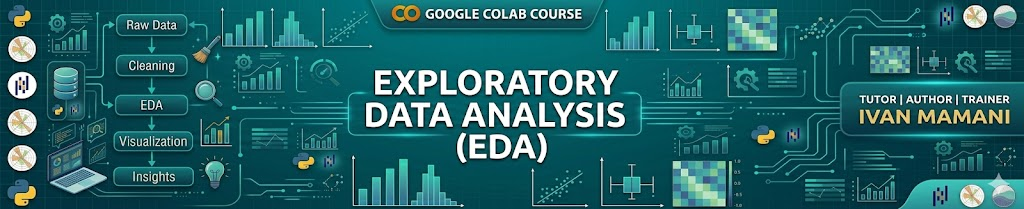

# Análise Exploratória – California Housing

**Dataset:** California Housing

**Fonte:** Biblioteca Scikit-Learn (dados derivados do Censo da Califórnia – 1990)

**Link:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

**Autor:** Ivan Mamani

---
## 1. Contexto Científico

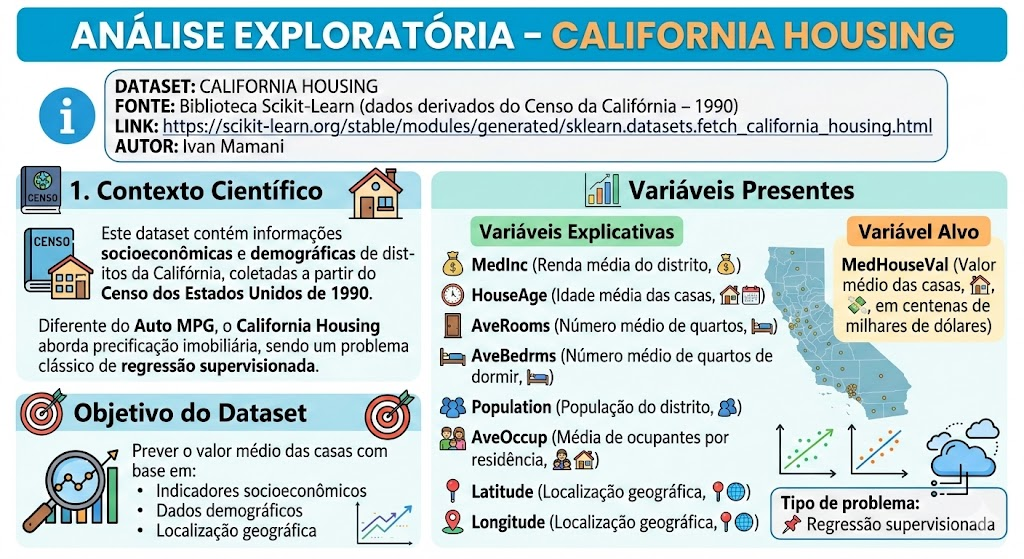

## 2. Importação das Bibliotecas

In [ ]:
# Importa pandas para manipulação de dados em formato de tabela
import pandas as pd

# Importa numpy para cálculos numéricos
import numpy as np

# Importa matplotlib para criação de gráficos
import matplotlib.pyplot as plt

# Importa seaborn para visualizações estatísticas
import seaborn as sns

# Importa a função para carregar o dataset California Housing
from sklearn.datasets import fetch_california_housing

# Define estilo visual para gráficos
sns.set(style="whitegrid")


## 3. Carregamento do Dataset

In [ ]:
# Carrega o dataset California Housing
data = fetch_california_housing()

# Converte os dados em DataFrame pandas
df = pd.DataFrame(data.data, columns=data.feature_names)

# Adiciona a variável alvo ao DataFrame
df["MedHouseVal"] = data.target

# Exibe as primeiras linhas do dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Insights e Interpretação**


> Este é um problema clássico de **regressão supervisionada**.

**❓ Perguntas de Reflexão**

- Por que é importante transformar os dados em DataFrame?
- O que significa “variável alvo”?
- Se todas as variáveis são numéricas, ainda precisamos de pré-processamento?

## 4. Estrutura e Limpeza dos Dados

In [ ]:
# Exibir as primeiras linhas do dataset
# Isso ajuda a visualizar como os dados estão organizados
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Verificar o formato do dataset (linhas e colunas)
# shape retorna uma tupla: (numero de linhas, numero de colunas)
df.shape

(20640, 9)

In [ ]:
# Verificar informações gerais do dataset
# info() mostra:
# - nome das colunas
# - tipos de dados
# - quantidade de valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Verificar valores nulos em cada coluna
# isnull() identifica valores nulos
# sum() conta quantos existem por coluna
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
# Verificar se existem linhas duplicadas
# duplicated() retorna True para linhas repetidas
df.duplicated().sum()

np.int64(0)

**Interpretação**

Esse dataset é considerado ***bem estruturado para aprendizado de Machine Learning***, pois:
- não possui valores faltantes
- possui apenas variáveis numéricas
- possui quantidade suficiente de dados

>Por isso ele é muito utilizado para ensinar regressão e análise exploratória.

Entretanto, mesmo datasets "limpos" ainda podem ter:
- outliers
- distribuições enviesadas
- relações não lineares

Esses aspectos serão explorados nos próximos blocos da análise.

**❓ Perguntas de Reflexão**
- ***Por que verificar valores nulos antes da análise estatística?***

- **Qual é a importância de verificar o tipo de dados das colunas?**

- **Mesmo sem valores nulos, o dataset pode ter problemas? Quais?**

## 5. Estatísticas Descritivas

In [ ]:
# Gera estatísticas descritivas do dataset
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**Insights e Interpretação**

> Isso indica heterogeneidade regional no mercado imobiliário.

**❓ Perguntas de Reflexão**

- **O que indica um desvio padrão alto?**

- **Por que verificar valores ausentes é importante?**

- **Qual variável parece ter maior variabilidade?**

## 6. Visualização das Distribuições
### 6.1. Histograma da variável alvo

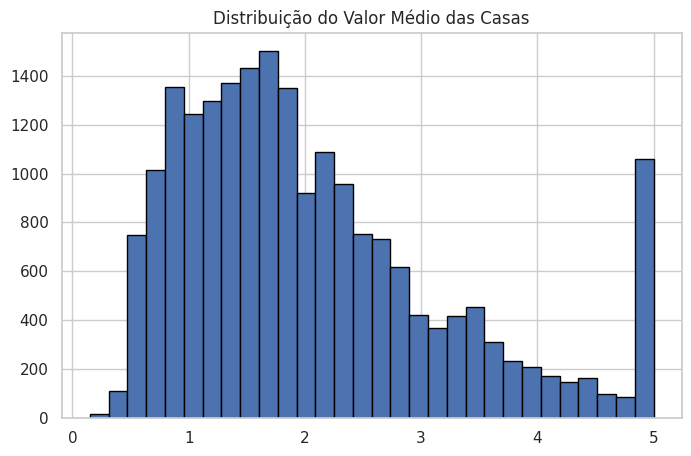

In [ ]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria histograma da variável MedHouseVal
plt.hist(df["MedHouseVal"], bins=30, edgecolor="black")

# Define título do gráfico
plt.title("Distribuição do Valor Médio das Casas")

# Exibe o gráfico
plt.show()

**Interpretação**


**❓ Perguntas**

- **A distribuição parece normal?**

- **O que significa assimetria positiva?**

- **Modelos lineares podem ser afetados por assimetria?**

### 6.2. Boxplot (Outliers)

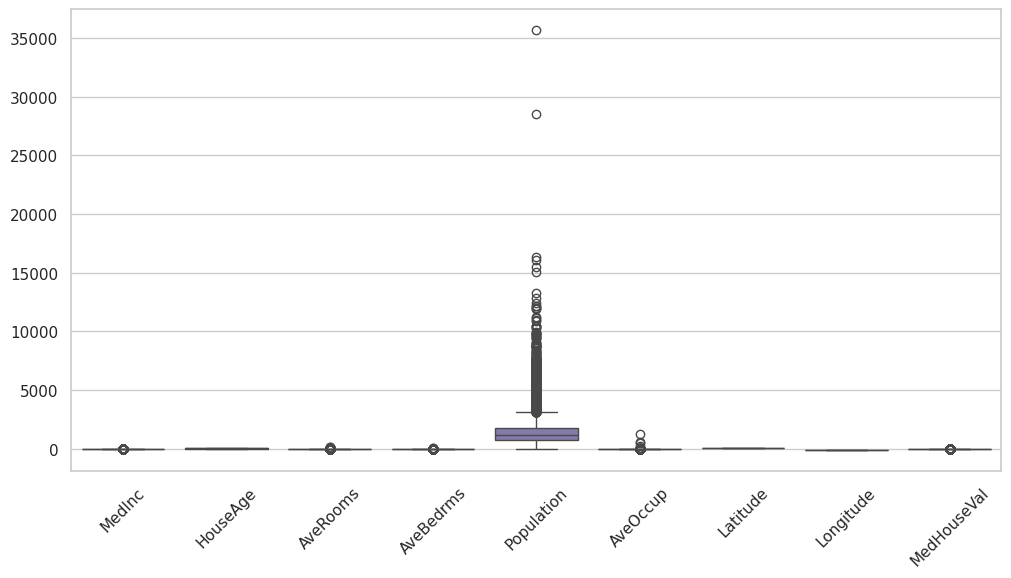

In [ ]:
# Define tamanho da figura
plt.figure(figsize=(12,6))

# Cria boxplot para todas as variáveis
sns.boxplot(data=df)

# Rotaciona os nomes das variáveis para melhor visualização
plt.xticks(rotation=45)

# Exibe o gráfico
plt.show()

**Interpretação**

**❓ Perguntas**

- **O que representa a caixa do boxplot?**

- **O que representam os pontos fora da caixa?**

- **Todo outlier deve ser removido?**

### 6.3. Scatter Plots
**Objetivo:** Visualizar relações entre variáveis explicativas e o preço das casas.

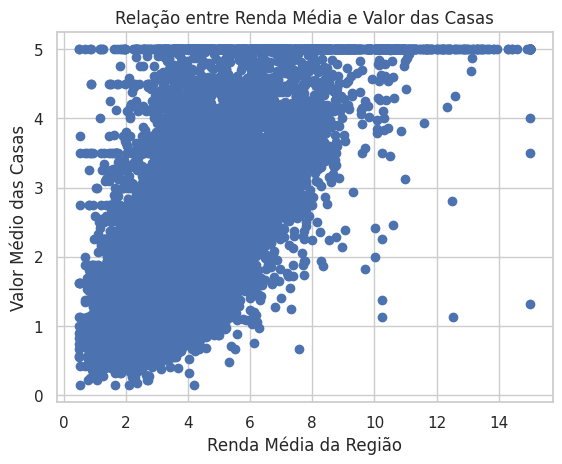

In [ ]:
# Scatter plot entre renda média da região e preço médio das casas
plt.scatter(df['MedInc'], df['MedHouseVal'])

# Define título do gráfico
plt.title('Relação entre Renda Média e Valor das Casas')

# Define rótulo do eixo X
plt.xlabel('Renda Média da Região')

# Define rótulo do eixo Y
plt.ylabel('Valor Médio das Casas')

# Mostra o gráfico
plt.show()

**Interpretação**

Este gráfico mostra a relação entre renda média da região (MedInc) e valor médio das casas (MedHouseVal).

**Observações importantes:**
- Existe correlação positiva clara
- Quanto maior a renda média da região, maior tende a ser o valor das casas
- A dispersão indica que outros fatores também influenciam o preço

> Esse tipo de gráfico ajuda a entender quais variáveis são mais promissoras para modelos de machine learning.

### 6.4. Matriz de Correlação

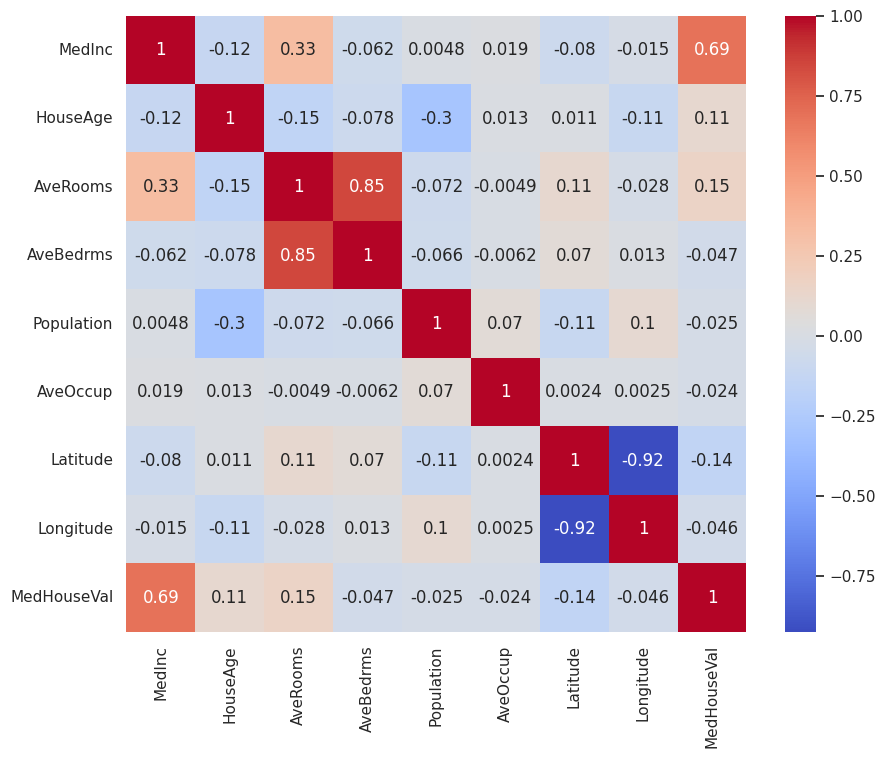

In [ ]:
# Calcula matriz de correlação entre variáveis
corr = df.corr()

# Define tamanho da figura
plt.figure(figsize=(10,8))

# Cria mapa de calor com valores de correlação
sns.heatmap(corr, annot=True, cmap="coolwarm")

# Exibe o gráfico
plt.show()

**Interpretação**

- MedInc possui forte correlação com MedHouseVal.
- Isso indica que renda média influencia preço das casas.
- Variáveis geográficas também têm impacto.

**❓ Perguntas**

- **Qual variável parece mais relacionada ao preço das casas?**

- **Correlação significa causalidade?**

- **O que é multicolinearidade?**

## Conclusão Científica

A análise exploratória revelou que:
- A renda média é o principal fator associado ao preço das casas.
- Existem outliers em variáveis populacionais.
- Algumas variáveis geográficas também influenciam valores imobiliários.

> O dataset agora **está preparado para modelagem preditiva**, permitindo aplicar modelos de regressão para prever valores imobiliários.